In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.models.train_balanced_bagging_ensemble import run_balanced_bagging
from src.splits.io import load_splits

import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix

from src.eval.plots import (
    plot_roc_curves,
    plot_pr_curves,
    plot_confusion_matrices,
    plot_probability_distributions,
)

paths = load_paths()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

In [2]:
def apply_split_lists(df: pd.DataFrame, train_list: Path, val_list: Path, test_list: Path, *, split_col: str = "split") -> pd.DataFrame:
    splits = load_splits(train_list, val_list, test_list)

    cap_to_split = {}
    for split_name, caps in splits.items():
        for cid in caps:
            cap_to_split[str(cid)] = split_name

    out = df.copy()
    # Normalize strings to ensure .pcap extensions don't break matching
    out["temp_id"] = out["capture_id"].astype(str).str.replace(".pcap", "").str.strip()
    clean_cap_to_split = {str(k).replace(".pcap", "").strip(): v for k, v in cap_to_split.items()}
    out[split_col] = out["temp_id"].map(clean_cap_to_split)


    missing_caps = sorted(out.loc[out[split_col].isna(), "capture_id"].unique().tolist())
    if missing_caps:
        raise ValueError(
            f"Found {len(missing_caps)} captures without split assignment. "
            f"Examples: {missing_caps[:10]}"
        )

    return out


def print_split_summary(df: pd.DataFrame, name: str):
    print(f"\n{name} split counts:")
    print(df["split"].value_counts(dropna=False))
    print(f"\n{name} label by split:")
    print(pd.crosstab(df["split"], df["label"]))


def print_capture_summary(df: pd.DataFrame, name: str):
    tmp = (
        df.groupby(["split", "dataset"])["capture_id"]
        .nunique()
        .unstack(fill_value=0)
    )
    print(f"\n{name} unique captures by split/dataset:")
    print(tmp)

In [3]:
logger.info("Re-extracting VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

if "q_min_packets_ok" in vnat_feats.columns:
    vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()

vnat_feats = apply_split_lists(
    vnat_feats,
    paths.data_splits / "vnat_train_captures.txt",
    paths.data_splits / "vnat_val_captures.txt",
    paths.data_splits / "vnat_test_captures.txt",
)

print_split_summary(vnat_feats, "VNAT")
print_capture_summary(vnat_feats, "VNAT")

2026-03-26 12:13:55 | INFO | ai-vpn-firewall | Re-extracting VNAT features...

VNAT split counts:
split
train    7750
test      210
val       147
Name: count, dtype: int64

VNAT label by split:
label     0    1
split           
test    197   13
train  7401  349
val     135   12

VNAT unique captures by split/dataset:
dataset  vnat
split        
test       26
train     115
val        24


In [4]:
logger.info("Re-extracting ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

if "q_min_packets_ok" in iscx_feats.columns:
    iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

iscx_feats = apply_split_lists(
    iscx_feats,
    paths.data_splits / "iscx_train_captures.txt",
    paths.data_splits / "iscx_val_captures.txt",
    paths.data_splits / "iscx_test_captures.txt",
)

print_split_summary(iscx_feats, "ISCX")
print_capture_summary(iscx_feats, "ISCX")

2026-03-26 12:16:04 | INFO | ai-vpn-firewall | Re-extracting ISCX features...

ISCX split counts:
split
train    8388
val      1779
test     1634
Name: count, dtype: int64

ISCX label by split:
label     0     1
split            
test   1396   238
train  6359  2029
val    1103   676

ISCX unique captures by split/dataset:
dataset  iscx
split        
test       21
train      98
val        21


In [5]:
logger.info("Loading USBVPN pre-extracted features...")
usbvpn_feats = pd.read_parquet(paths.data_processed / "usbvpn" / "flows.parquet")
usbvpn_feats["dataset"] = "usbvpn"

# The split is already in the parquet file for usbvpn
print_split_summary(usbvpn_feats, "USBVPN")
print_capture_summary(usbvpn_feats, "USBVPN")

2026-03-26 12:17:51 | INFO | ai-vpn-firewall | Loading USBVPN pre-extracted features...

USBVPN split counts:
split
train    41833
test      9002
val       8142
Name: count, dtype: int64

USBVPN label by split:
label      0     1
split             
test    7643  1359
train  35076  6757
val     7472   670

USBVPN unique captures by split/dataset:
dataset  usbvpn
split          
test         77
train       352
val          75


In [6]:
df_all = pd.concat([vnat_feats, iscx_feats, usbvpn_feats], ignore_index=True)

df_all["split"] = df_all["split"].astype(str)

valid_splits = {"train", "val", "test"}
bad_splits = sorted(set(df_all["split"].unique()) - valid_splits)
if bad_splits:
    raise ValueError(f"Unexpected split values found: {bad_splits}")

print("\nFINAL combined split counts:")
print(df_all["split"].value_counts())

print("\nFINAL combined label by split:")
print(pd.crosstab(df_all["split"], df_all["label"]))

print("\nFINAL combined dataset by split:")
print(pd.crosstab(df_all["split"], df_all["dataset"]))

print("\nFINAL combined unique captures by split/dataset:")
print(
    df_all.groupby(["split", "dataset"])["capture_id"]
    .nunique()
    .unstack(fill_value=0)
)


FINAL combined split counts:
split
train    57971
test     10846
val      10068
Name: count, dtype: int64

FINAL combined label by split:
label      0     1
split             
test    9236  1610
train  48836  9135
val     8710  1358

FINAL combined dataset by split:
dataset  iscx  usbvpn  vnat
split                      
test     1634    9002   210
train    8388   41833  7750
val      1779    8142   147

FINAL combined unique captures by split/dataset:
dataset  iscx  usbvpn  vnat
split                      
test       21      77    26
train      98     352   115
val        21      75    24


In [7]:
logger.info("Fitting FeaturePipeline...")
pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"])

feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))

feature_cols = pipeline.model_feature_names()
logger.info(f"Pipeline saved. Model features: {len(feature_cols)}")
print("Model feature count:", len(feature_cols))
print("First 30 model features:", feature_cols[:30])

2026-03-26 12:17:52 | INFO | ai-vpn-firewall | Fitting FeaturePipeline...
2026-03-26 12:17:54 | INFO | ai-vpn-firewall | Pipeline saved. Model features: 39
Model feature count: 39
First 30 model features: ['sz_cv', 'sz_all_mean', 'sz_all_std', 'sz_all_p25', 'sz_all_median', 'sz_all_p75', 'sz_mean_max', 'sz_mean_min', 'sz_std_max', 'sz_std_min', 'iat_all_mean', 'iat_all_std', 'iat_all_p25', 'iat_all_median', 'iat_all_p75', 'iat_mean_max', 'iat_mean_min', 'iat_std_max', 'iat_std_min', 'h_size_all_00', 'h_size_all_01', 'h_size_all_02', 'h_size_all_03', 'h_size_all_04', 'h_size_all_05', 'h_size_all_06', 'h_iat_all_00', 'h_iat_all_01', 'h_iat_all_02', 'h_iat_all_03']


In [8]:
logger.info("Transforming features for training...")
df_transformed = pipeline.transform(df_all)

meta_cols = ["label", "split", "capture_id", "dataset", "flow_id"]
for col in meta_cols:
    df_transformed[col] = df_all[col].values

print("Transformed shape:", df_transformed.shape)
print(df_transformed["split"].value_counts())
print(pd.crosstab(df_transformed["split"], df_transformed["dataset"]))

2026-03-26 12:17:54 | INFO | ai-vpn-firewall | Transforming features for training...
Transformed shape: (78885, 46)
split
train    57971
test     10846
val      10068
Name: count, dtype: int64
dataset  iscx  usbvpn  vnat
split                      
test     1634    9002   210
train    8388   41833  7750
val      1779    8142   147


In [9]:
logger.info("Training LightGBM (Balanced Bagging)...")

results = run_balanced_bagging(
    df=df_transformed,
    label_col="label",
    group_col="capture_id",
    dataset_col="dataset",
    split_col="split",
    bags_per_family=3,
    majority_ratio=1.0,
    target_fprs="0.001,0.005,0.01",
    seed=42,
    output_dir=str(paths.artifacts_dir / "balanced_bagging_lgbm"),
    model_types=["lgbm"],
    feature_cols=feature_cols,
    weight_xgb=1.0,
    weight_lgbm=1.0,
    weight_cat=1.0,
)

2026-03-26 12:17:56 | INFO | ai-vpn-firewall | Training LightGBM (Balanced Bagging)...


In [10]:
print("\n" + "=" * 60)
print("LIGHTGBM EVALUATION (BALANCED BAGGING)")
print("=" * 60)

def print_metrics(name, metrics_dict):
    print(f"\n--- {name} ---")
    if "auc" in metrics_dict and metrics_dict["auc"] is not None:
        print(f"ROC AUC: {metrics_dict['auc']:.4f}")
    if "pr_auc" in metrics_dict and metrics_dict["pr_auc"] is not None:
        print(f"PR AUC:  {metrics_dict['pr_auc']:.4f}")

    for key, val in metrics_dict.items():
        if key.startswith("fpr_"):
            print(f"\nPolicy: {key}")
            print(f"  Threshold: {val['threshold']:.4f}")
            print(f"  Recall:    {val['recall']:.4f}")
            print(f"  Precision: {val['precision']:.4f}")
            print(f"  FPR:       {val['fpr']:.5f}")
            cm = val["confusion"]
            print(f"  Confusion: TN={cm['tn']}, FP={cm['fp']}, FN={cm['fn']}, TP={cm['tp']}")

if "val" in results:
    print_metrics("VALIDATION SET", results["val"])

if "test_overall" in results:
    print_metrics("TEST SET (OVERALL)", results["test_overall"])

for key in results:
    if key.startswith("test_") and key != "test_overall":
        print_metrics(f"TEST SET ({key.replace('test_', '').upper()})", results[key])

print("\n" + "=" * 60)


LIGHTGBM EVALUATION (BALANCED BAGGING)




Predictions columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'p_calib', 'split']

--- RAW vs CALIBRATED COMPARISON (LightGBM) ---

Split: val
ROC AUC     raw=0.9971  calib=0.9977
PR AUC      raw=0.9875  calib=0.9861
Brier       raw=0.0108  calib=0.0096
LogLoss     raw=0.0394  calib=0.0339

Split: test
ROC AUC     raw=0.9974  calib=0.9968
PR AUC      raw=0.9895  calib=0.9839
Brier       raw=0.0102  calib=0.0109
LogLoss     raw=0.0396  calib=0.0448

--- Generating Plots for LightGBM (Calibrated) ---


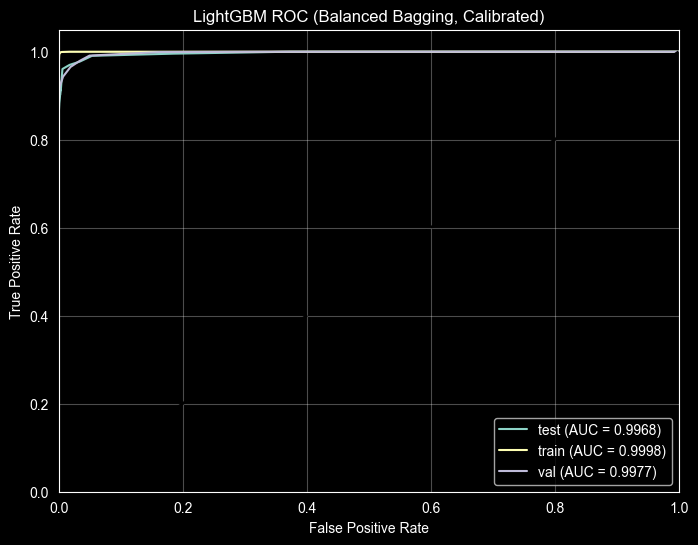

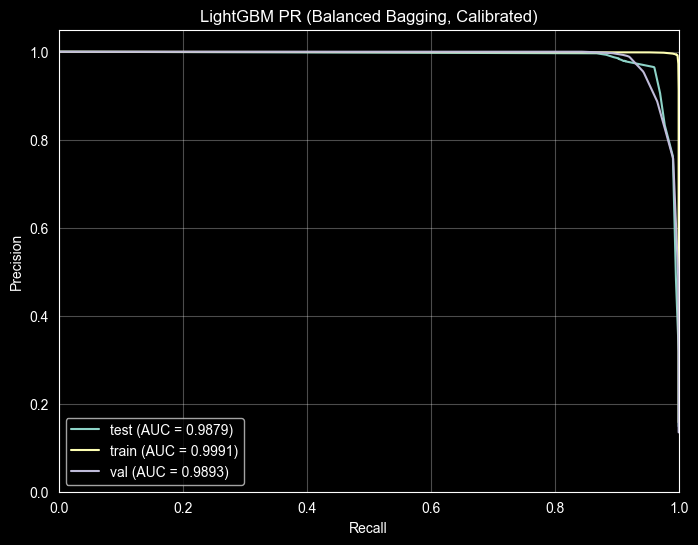

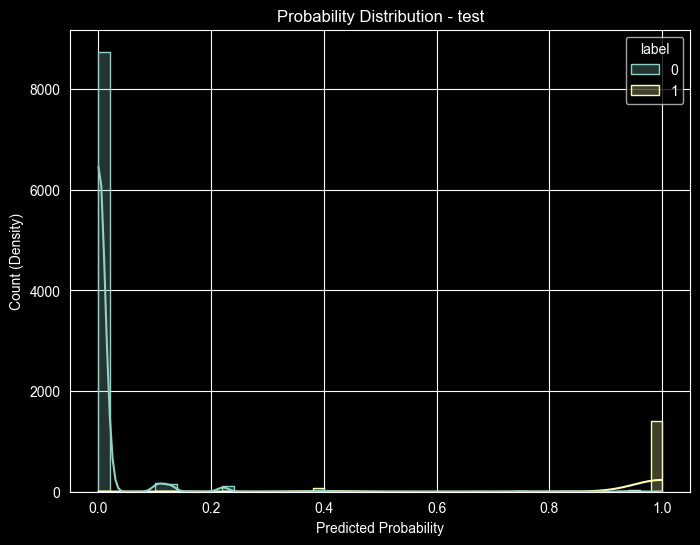

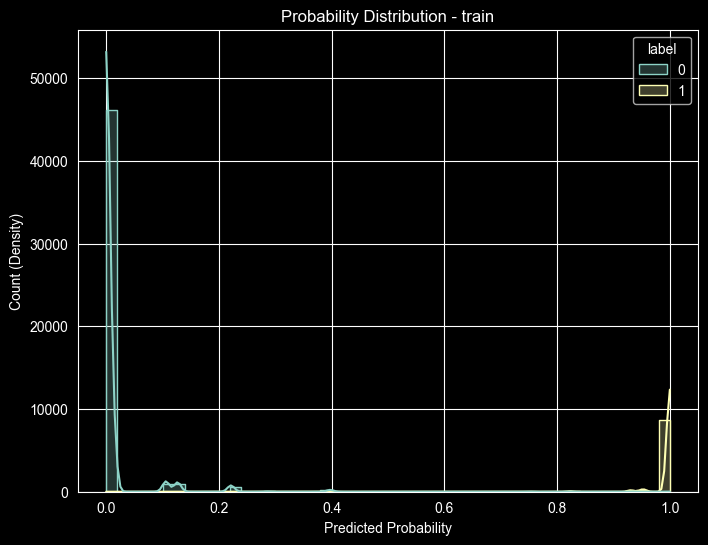

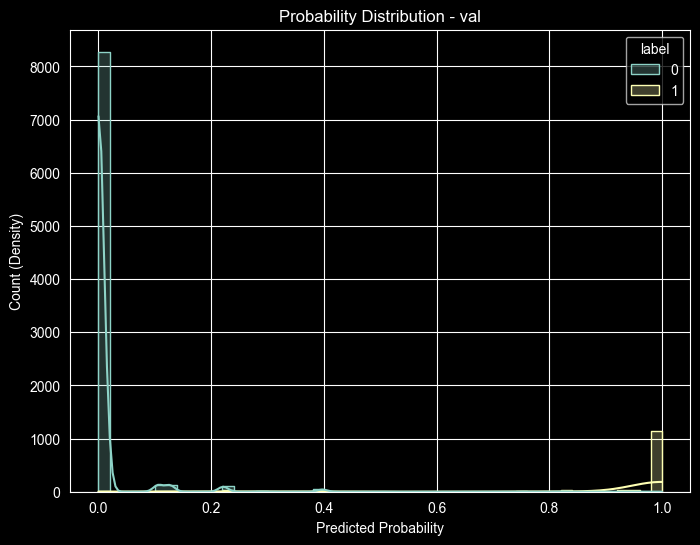


--- Confusion Matrices at Policy Thresholds (Test Set, Calibrated) ---


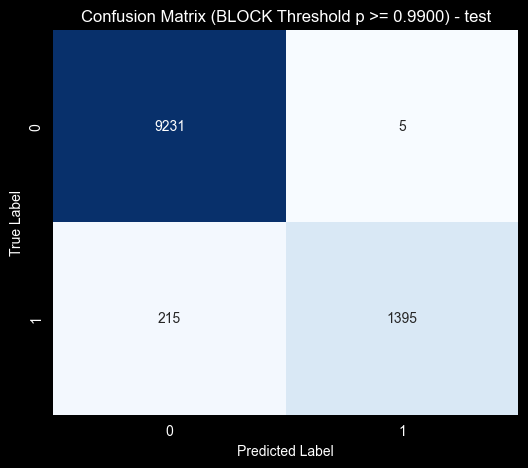

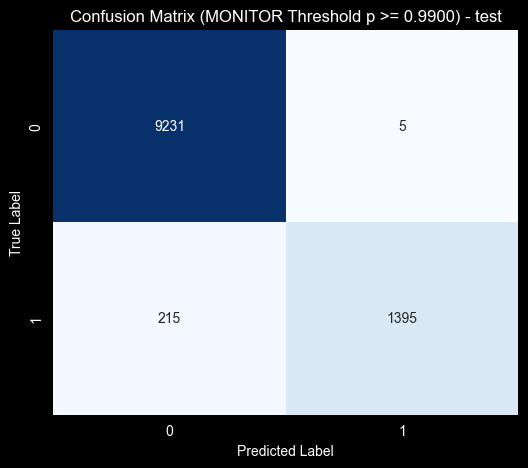

In [11]:
preds_path = paths.artifacts_dir / "balanced_bagging_lgbm" / "predictions.csv"

if preds_path.exists():
    df_preds = pd.read_csv(preds_path)

    # After isotonic calibration in run_balanced_bagging, predictions.csv should contain:
    # - prob_raw : raw ensemble score
    # - prob     : calibrated ensemble score
    if "prob" not in df_preds.columns:
        raise ValueError("Missing calibrated probability column 'prob' in predictions.csv")
    if "prob_raw" not in df_preds.columns:
        raise ValueError("Missing raw probability column 'prob_raw' in predictions.csv")

    df_preds = df_preds.rename(columns={"prob": "p_calib"})

    print("\nPredictions columns:")
    print(df_preds.columns.tolist())

    from sklearn.metrics import brier_score_loss, log_loss

    print("\n--- RAW vs CALIBRATED COMPARISON (LightGBM) ---")
    for split_name in ["val", "test"]:
        sub = df_preds[df_preds["split"] == split_name].copy()
        if sub.empty:
            continue

        y = sub["label"].astype(int)

        auc_raw = roc_auc_score(y, sub["prob_raw"])
        auc_cal = roc_auc_score(y, sub["p_calib"])

        ap_raw = average_precision_score(y, sub["prob_raw"])
        ap_cal = average_precision_score(y, sub["p_calib"])

        brier_raw = brier_score_loss(y, sub["prob_raw"])
        brier_cal = brier_score_loss(y, sub["p_calib"])

        ll_raw = log_loss(y, np.clip(sub["prob_raw"], 1e-6, 1 - 1e-6))
        ll_cal = log_loss(y, np.clip(sub["p_calib"], 1e-6, 1 - 1e-6))

        print(f"\nSplit: {split_name}")
        print(f"ROC AUC     raw={auc_raw:.4f}  calib={auc_cal:.4f}")
        print(f"PR AUC      raw={ap_raw:.4f}  calib={ap_cal:.4f}")
        print(f"Brier       raw={brier_raw:.4f}  calib={brier_cal:.4f}")
        print(f"LogLoss     raw={ll_raw:.4f}  calib={ll_cal:.4f}")

    print("\n--- Generating Plots for LightGBM (Calibrated) ---")
    plot_roc_curves(df_preds, prob_col="p_calib", title="LightGBM ROC (Balanced Bagging, Calibrated)")
    plot_pr_curves(df_preds, prob_col="p_calib", title="LightGBM PR (Balanced Bagging, Calibrated)")
    plot_probability_distributions(df_preds, prob_col="p_calib")

    val_metrics = results.get("val", {})

    def get_thr(metrics_dict, fpr):
        key = f"fpr_{fpr}"
        if key in metrics_dict:
            return metrics_dict[key]["threshold"]
        return 0.99

    T_BLOCK = get_thr(val_metrics, 0.001)
    T_MONITOR = get_thr(val_metrics, 0.01)

    print("\n--- Confusion Matrices at Policy Thresholds (Test Set, Calibrated) ---")
    test_preds = df_preds[df_preds["split"] == "test"].copy()

    plot_confusion_matrices(
        test_preds,
        prob_col="p_calib",
        threshold=T_BLOCK,
        title=f"Confusion Matrix (BLOCK Threshold p >= {T_BLOCK:.4f})"
    )

    plot_confusion_matrices(
        test_preds,
        prob_col="p_calib",
        threshold=T_MONITOR,
        title=f"Confusion Matrix (MONITOR Threshold p >= {T_MONITOR:.4f})"
    )
else:
    print("Predictions file not found, skipping plots.")


--- Reliability Diagram (Test Set) ---


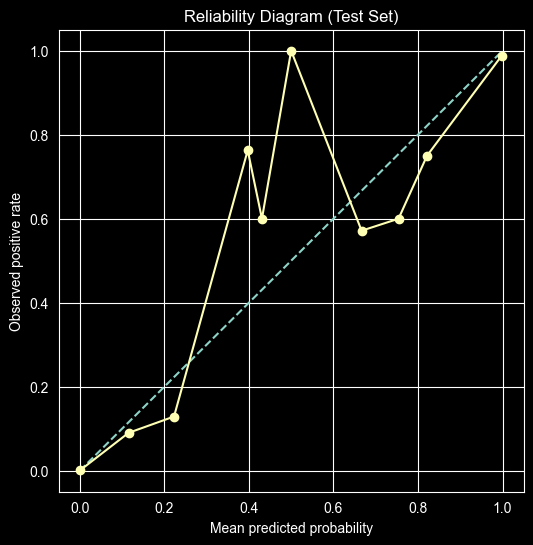

   bin_pred_mean  bin_obs_rate  count
0       0.001681      0.001714   8754
1       0.115369      0.090164    366
2       0.222931      0.129032    124
3       0.397260      0.762887     97
4       0.430897      0.600000      5
5       0.500000      1.000000      3
6       0.666667      0.571429      7
7       0.754001      0.600000     15
8       0.821429      0.750000     16
9       0.997706      0.987663   1459


In [12]:
def plot_reliability_curve(y_true, y_prob, n_bins=10, title="Reliability Diagram"):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    pred_means = []
    obs_rates = []
    counts = []

    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        pred_means.append(y_prob[mask].mean())
        obs_rates.append(y_true[mask].mean())
        counts.append(mask.sum())

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(pred_means, obs_rates, marker="o")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title(title)
    plt.grid(True)
    plt.show()

    return pd.DataFrame({
        "bin_pred_mean": pred_means,
        "bin_obs_rate": obs_rates,
        "count": counts,
    })

if "df_preds" in locals():
    # Fix for potential missing column rename if cells run out of order
    if "p_calib" not in df_preds.columns and "prob" in df_preds.columns:
        df_preds = df_preds.rename(columns={"prob": "p_calib"})

    if "p_calib" in df_preds.columns:
        print("\n--- Reliability Diagram (Test Set) ---")
        test_preds = df_preds[df_preds["split"] == "test"].copy()
        rel_df = plot_reliability_curve(
            test_preds["label"],
            test_preds["p_calib"],
            n_bins=10,
            title="Reliability Diagram (Test Set)"
        )
        print(rel_df)
    else:
        print("Error: 'p_calib' column not found in df_preds. Check if predictions were loaded correctly.")
else:
    print("df_preds not found. Run the previous cell to load predictions.")